In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [6]:
import pandas as pd

import os
os.listdir('/kaggle/input/datasets/vincenthope/funeldata1/')

In [8]:
#Read & Display Data
data = pd.read_csv("/kaggle/input/datasets/vincenthope/funeldata1/Ecommerce_Funnel1.csv")

data.head(5)

,visit_id,session_id,date,traffic_source,device,page_views,product_views,add_to_cart,checkout_started,purchase,revenue_usd
0,V00001,S00001,6/15/2026,Organic,Mobile,6,0,0,0,0,0.0
1,V00002,S00002,3/18/2026,Organic,Mobile,14,9,0,0,0,0.0
2,V00003,S00003,6/1/2026,Direct,Desktop,9,3,0,0,0,0.0
3,V00004,S00004,6/2/2026,Referral,Mobile,10,7,1,0,0,0.0
4,V00005,S00005,1/2/2026,Direct,Tablet,13,13,0,0,0,0.0


In [11]:
# Calculate Funnel Counts from External Data
stages = [
    "visit_id",
    "product_views",
    "add_to_cart",
    "purchase"
]

funnel_counts = {
    "visit_id": data["session_id"].nunique(),
    "product_views": data[data["product_views"] > 0]["session_id"].nunique(),
    "add_to_cart": data[data["add_to_cart"] > 0]["session_id"].nunique(),
    "purchase": data[data["purchase"] > 0]["session_id"].nunique()
}

print(funnel_counts)


{'visit_id': 2000, 'product_views': 1779, 'add_to_cart': 608, 'purchase': 265}


In [22]:
#Overall Conversion Rate
#Formula:Conversion Rate=PurchasesVisitors×100Conversion\ Rate = \frac{Purchases}{Visitors} \times 100Conversion Rate=VisitorsPurchases×100

overall_conversion = (
    funnel_counts["purchase"] /
    funnel_counts["visit_id"]
) * 100

print(f"{overall_conversion:.2f}%")


13.25%


In [12]:
#Calculate Conversion Rates
for i in range(1, len(stages)):
    prev_stage = stages[i-1]
    curr_stage = stages[i]

    rate = (
        funnel_counts[curr_stage]
        / funnel_counts[prev_stage]
    ) * 100

    print(
        f"{prev_stage} → {curr_stage}: "
        f"{rate:.2f}%"
    )


visit_id → product_views: 88.95%
product_views → add_to_cart: 34.18%
add_to_cart → purchase: 43.59%


In [15]:
# Identify the Biggest Bottleneck

funnel_df = pd.DataFrame(
    list(funnel_counts.items()),
    columns=["stage", "users"]
)

funnel_df["dropoff"] = (
    funnel_df["users"].shift(1)
    - funnel_df["users"]
)

funnel_df["dropoff_pct"] = (
    funnel_df["dropoff"]
    / funnel_df["users"].shift(1)
) * 100

print(funnel_df)

           stage  users  dropoff  dropoff_pct
0       visit_id   2000      NaN          NaN
1  product_views   1779    221.0    11.050000
2    add_to_cart    608   1171.0    65.823496
3       purchase    265    343.0    56.414474


In [17]:
#Find the largest drop-off:
bottleneck = funnel_df.loc[
    funnel_df["dropoff_pct"].idxmax()
]

print(
    f"Biggest bottleneck: {bottleneck['stage']}"
)


Biggest bottleneck: add_to_cart


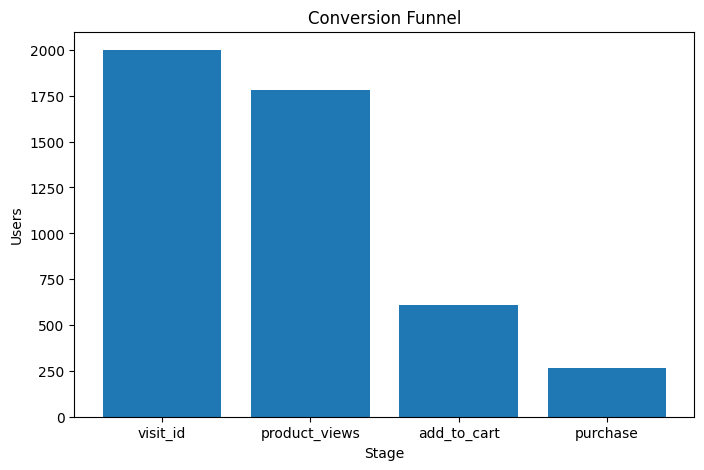

In [23]:
# Visualize the Funnel- Funnel Bar Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    funnel_df["stage"],
    funnel_df["users"]
)

plt.title("Conversion Funnel")
plt.xlabel("Stage")
plt.ylabel("Users")

plt.show()
